In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_2A, CONTEXTS_FEATURES_2A

data = "dream_cytof"
filename = "evaluate_all_figure2a"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)

In [31]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [32]:
val_df.samples.unique()

array(['EVSAT', 'HCC1500', 'BT20', 'UACC3199', 'MCF7'], dtype=object)

In [33]:
val_df[val_df.ref == "DMM"].groupby(["model", "context"]).rmse.mean()

model                           context                    
EGFR_MAPK__logobs               cytof_init                     0.527314
                                cytof_init_plus_intr           0.514161
                                cytof_init_plus_lb             0.516484
                                cytof_init_plus_pEGFR          0.531810
                                cytof_init_plus_tEGFR          0.544537
                                cytof_init_plus_tEGFR_pEGFR    0.505191
EGFR_MAPK__logobs_fegfr_aggavg  cytof_init                     0.592362
                                cytof_init_plus_intr           0.555761
                                cytof_init_plus_lb             0.487568
                                cytof_init_plus_pEGFR          0.501446
                                cytof_init_plus_tEGFR          0.527104
                                cytof_init_plus_tEGFR_pEGFR    0.521335
Name: rmse, dtype: float64

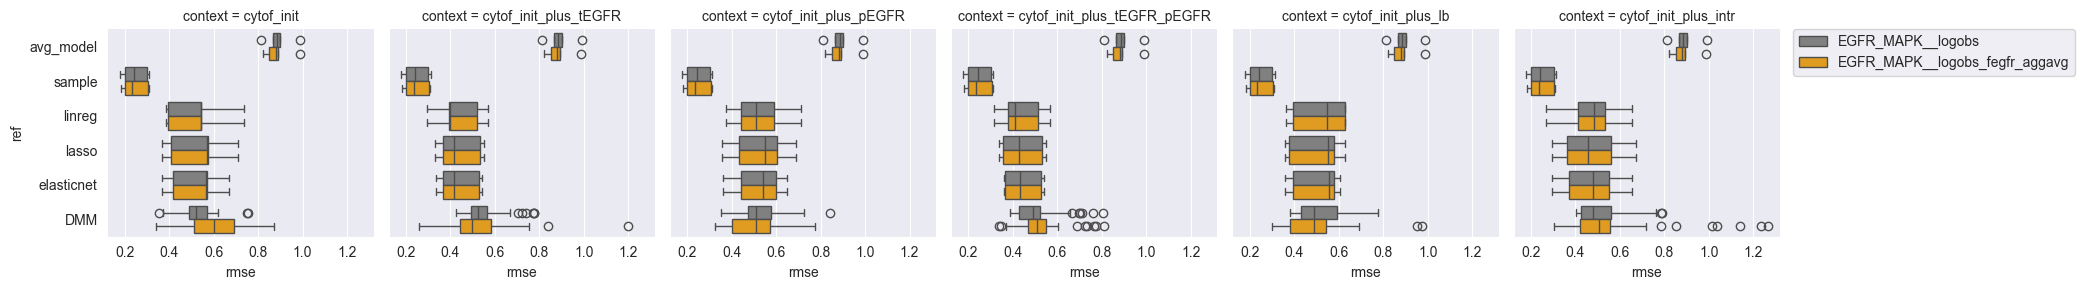

In [34]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

g = sns.FacetGrid(
    val_df,
    col="context",
    col_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Let's zoom in on DMMs only (regressors are not affected by model choice), comparing model/context combos

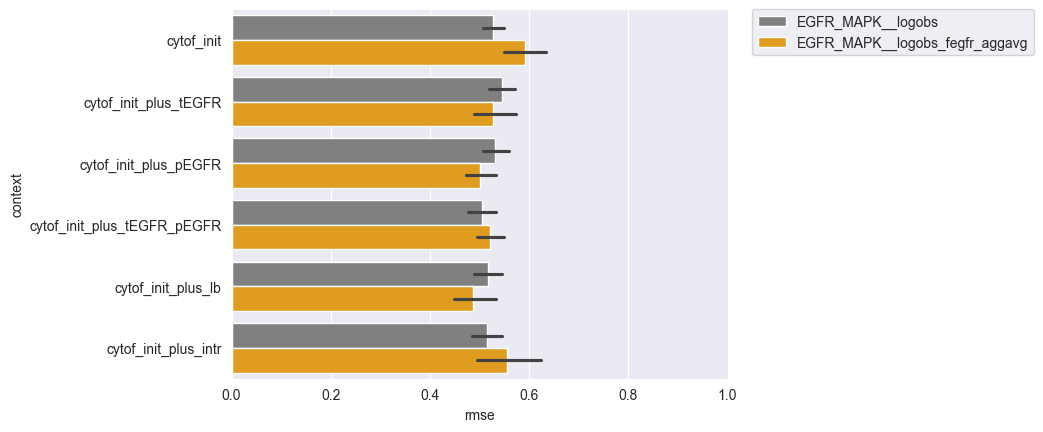

In [35]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.barplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr",
    ],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

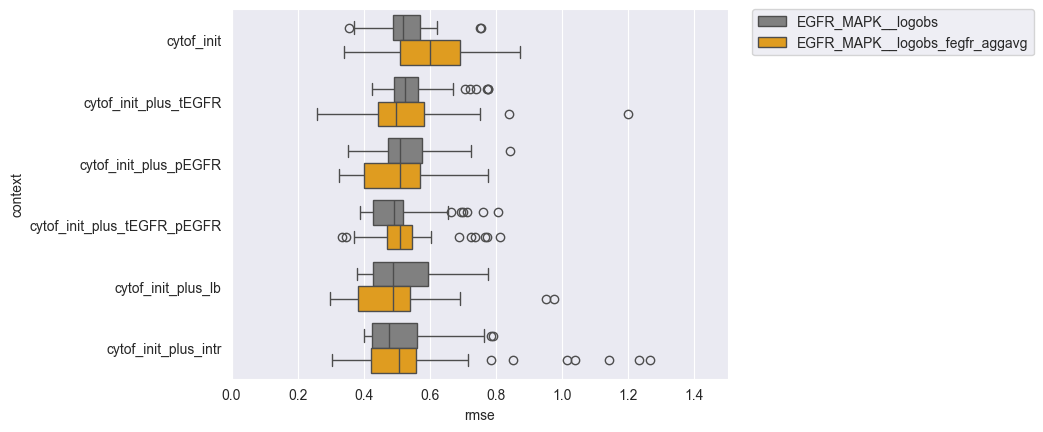

In [36]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.boxplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ],
    hue="model",
    palette=palette
)
plt.xlim([0, 1.5])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# If we look at `samples`-split, we notice we don't really get better on BT-20 (which is what we expected?), but we get better on UACC-3199. Unfortunately, we also get quite worse on EVSA-T.

(0.0, 1.0)

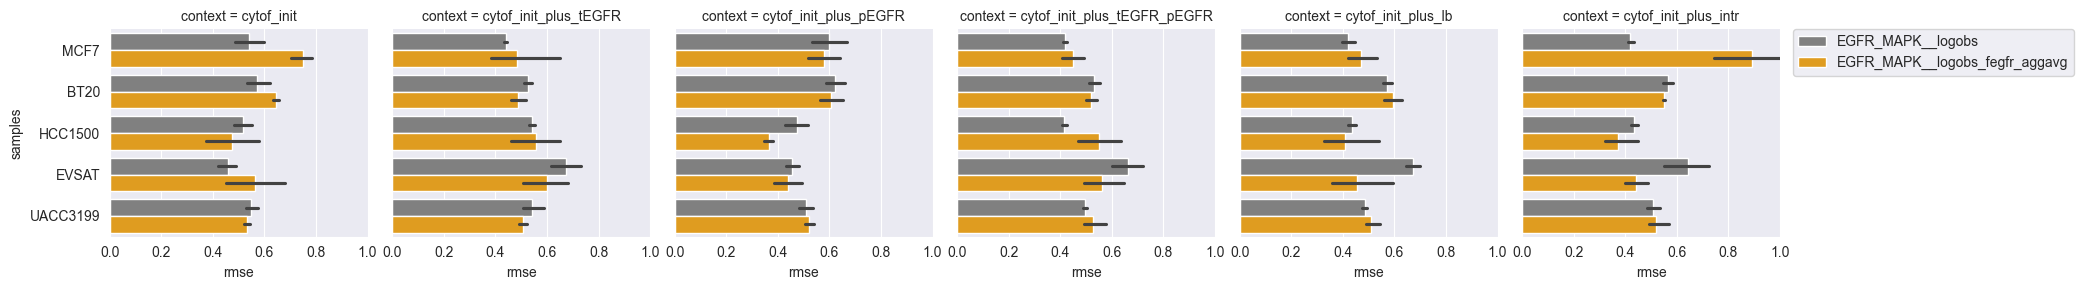

In [37]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
}

g = sns.FacetGrid(
    val_df[val_df.ref == "DMM"],
    col="context",
    col_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ]
)

g.map_dataframe(
    sns.barplot,
    x="rmse",
    y="samples",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"],
    palette=palette
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlim([0, 1])

In [47]:
val_df[
    ((val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs")) |
    ((val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
].groupby(["ref", "model", "context", "samples"]).rmse.mean()

ref         model                           context                samples 
DMM         EGFR_MAPK__logobs               cytof_init             BT20        0.570556
                                                                   EVSAT       0.457633
                                                                   HCC1500     0.518661
                                                                   MCF7        0.540066
                                                                   UACC3199    0.549653
            EGFR_MAPK__logobs_fegfr_aggavg  cytof_init_plus_tEGFR  BT20        0.489085
                                                                   EVSAT       0.599069
                                                                   HCC1500     0.556826
                                                                   MCF7        0.483950
                                                                   UACC3199    0.506592
avg_model   EGFR_MAPK__logobs               

<Axes: xlabel='rmse', ylabel='ref'>

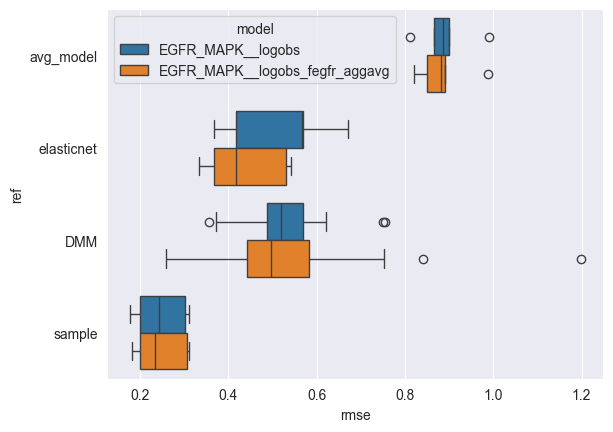

In [53]:
sns.boxplot(
    val_df[
        ((val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs")) |
        ((val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
    ],
    y="ref",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    x="rmse",
    hue="model",
)

In [82]:
from scipy import stats

target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=904.0, p=0.004696


Adding LB subtype and switching model produces a significant improvement

In [86]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "elasticnet")].sort_values(by=["samples"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].groupby("samples").rmse.mean().values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=9.0, p=0.4062


But even cytof_init_plus_LB does not perform better than regressors trained on that context...

<Axes: xlabel='rmse', ylabel='ref'>

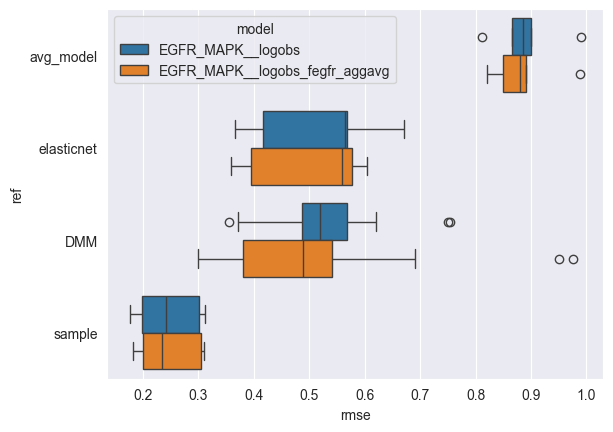

In [54]:
sns.boxplot(
    val_df[
        ((val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs")) |
        ((val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
    ],
    y="ref",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    x="rmse",
    hue="model",
)

# Let's restrict to `__logobs_fegr_aggavg` and compare with baselines and regressors

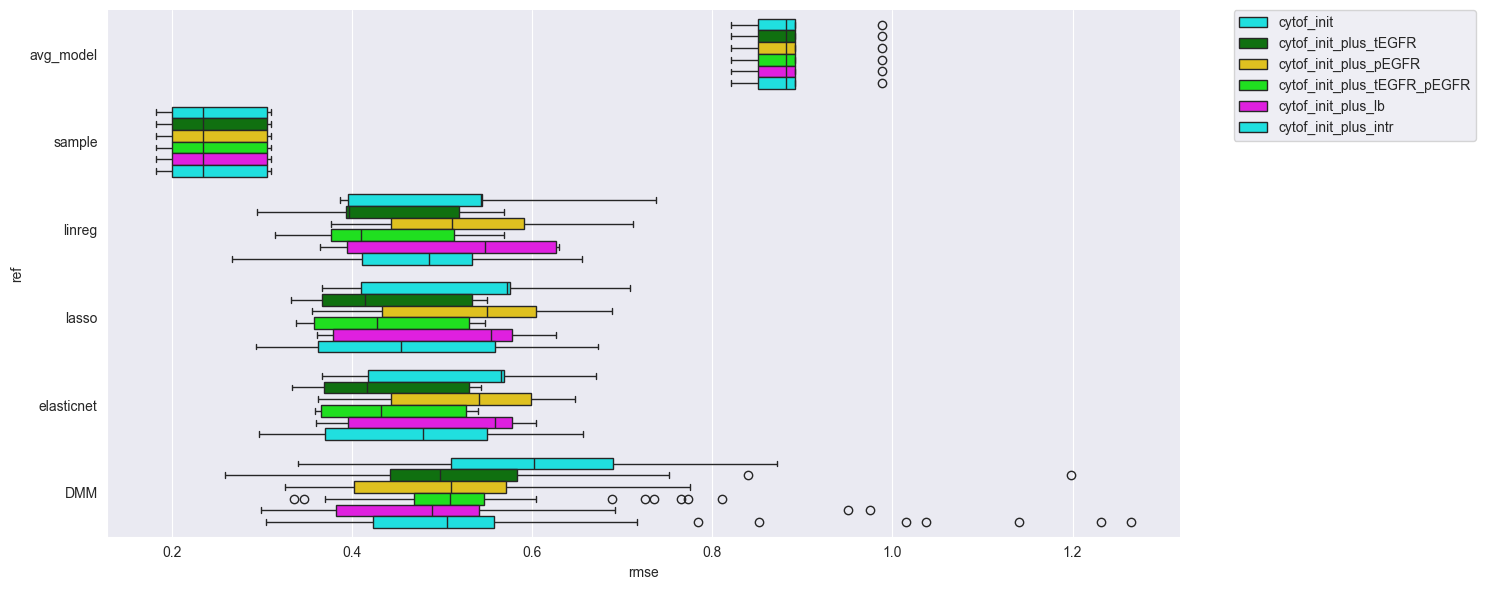

In [9]:
context_palette = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "green",
    "cytof_init_plus_pEGFR": "gold",
    "cytof_init_plus_tEGFR_pEGFR": "lime",
    "cytof_init_plus_lb": "magenta",
    "cytof_init_plus_intr": "cyan"
}

g = sns.FacetGrid(
    val_df[val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"],
    height=6,
    aspect=2
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="context",
    hue_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ],
    palette=context_palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [10]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

In [11]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: cytof_init_plus_pEGFR - Kruskal-Wallis H-test: H-statistic=1.28, p-value=0.2582
Context: cytof_init_plus_tEGFR - Kruskal-Wallis H-test: H-statistic=2.30, p-value=0.1294
Context: cytof_init_plus_intr - Kruskal-Wallis H-test: H-statistic=0.17, p-value=0.6791
Context: cytof_init_plus_lb - Kruskal-Wallis H-test: H-statistic=1.88, p-value=0.1701
Context: cytof_init_plus_tEGFR_pEGFR - Kruskal-Wallis H-test: H-statistic=2.04, p-value=0.1536
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=7.01, p-value=0.0081


# No clear improvement (anymore, using 1-2 `l1reg_inflater_output`) when changing model per-se from `__logobs` to `__logobs_fegfr_aggavg` (above). Clear significant worsening when going to `fegfr_aggavg_pobs` (below)

# But is there an improvement in going from `__logobs` with `cytof_init` to `__logobs_fegfr_aggavg` with `cytof_init_plus_tEGFR` or `cytof_init_plus_lb`? Or `__logobs_fegfr_aggavg_pobs` with `cytof_init_plus_tEGFR_pEGFR`? No, yes, yes/no. Only significant improvement seems to be with `lb` augmentation!?

In [12]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=0.97, p-value=0.3242, significant? False


In [13]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=550.0, p=0.4043


In [14]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=6.37, p-value=0.0116, significant? True


In [15]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=420.0, p=0.03539


In [16]:
val_df.groupby(["model", "context"]).rmse.mean()

model                           context                    
EGFR_MAPK__logobs               cytof_init                     0.531635
                                cytof_init_plus_intr           0.512415
                                cytof_init_plus_lb             0.520786
                                cytof_init_plus_pEGFR          0.535021
                                cytof_init_plus_tEGFR          0.526184
                                cytof_init_plus_tEGFR_pEGFR    0.500573
EGFR_MAPK__logobs_fegfr_aggavg  cytof_init                     0.574749
                                cytof_init_plus_intr           0.539897
                                cytof_init_plus_lb             0.501257
                                cytof_init_plus_pEGFR          0.514527
                                cytof_init_plus_tEGFR          0.514311
                                cytof_init_plus_tEGFR_pEGFR    0.511084
Name: rmse, dtype: float64

# Embeddings

In [17]:
from common import basedir, evaluations_dir

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure2a.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_2A
    ]
)

In [18]:
from embedding_utils import perform_pca_on_embeddings

pca_embeddings_dict = {}
for model in PATHWAYS_2A:
    print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model])

EGFR_MAPK__logobs
Explained variance for cytof_init BT20: 0.9572
Explained variance for cytof_init EVSAT: 0.9651
Explained variance for cytof_init HCC1500: 0.9827
Explained variance for cytof_init MCF7: 0.9687
Explained variance for cytof_init UACC3199: 0.9923
Explained variance for cytof_init_plus_intr BT20: 0.9752
Explained variance for cytof_init_plus_intr EVSAT: 0.9273
Explained variance for cytof_init_plus_intr HCC1500: 0.9507
Explained variance for cytof_init_plus_intr MCF7: 0.9496
Explained variance for cytof_init_plus_intr UACC3199: 0.9313
Explained variance for cytof_init_plus_lb BT20: 0.9428
Explained variance for cytof_init_plus_lb EVSAT: 0.9988
Explained variance for cytof_init_plus_lb HCC1500: 0.9738
Explained variance for cytof_init_plus_lb MCF7: 0.9311
Explained variance for cytof_init_plus_lb UACC3199: 0.9808
Explained variance for cytof_init_plus_pEGFR BT20: 0.9366
Explained variance for cytof_init_plus_pEGFR EVSAT: 0.9818
Explained variance for cytof_init_plus_pEGFR H

In [19]:
import warnings

warnings.filterwarnings("ignore")

subtypes_marcotte = pd.read_csv(basedir / "cell_line_subtypes.txt", delimiter='\t')
subtypes_marcotte["cell_line"] = subtypes_marcotte["cell_line"].apply(lambda x: "c"+x.upper())
subtypes_marcotte.cell_line.replace("cHS578T", "cHs578T", inplace=True)
subtypes_marcotte.cell_line.replace("c600MPE", "cMPE600", inplace=True)
subtypes_marcotte.sort_values(by="cell_line", inplace=True)
subtypes_marcotte.set_index("cell_line", inplace=True)
subtypes_marcotte = subtypes_marcotte.loc[pca_embeddings_dict["EGFR_MAPK__logobs"].index.unique()]

In [20]:
for model in PATHWAYS_2A:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

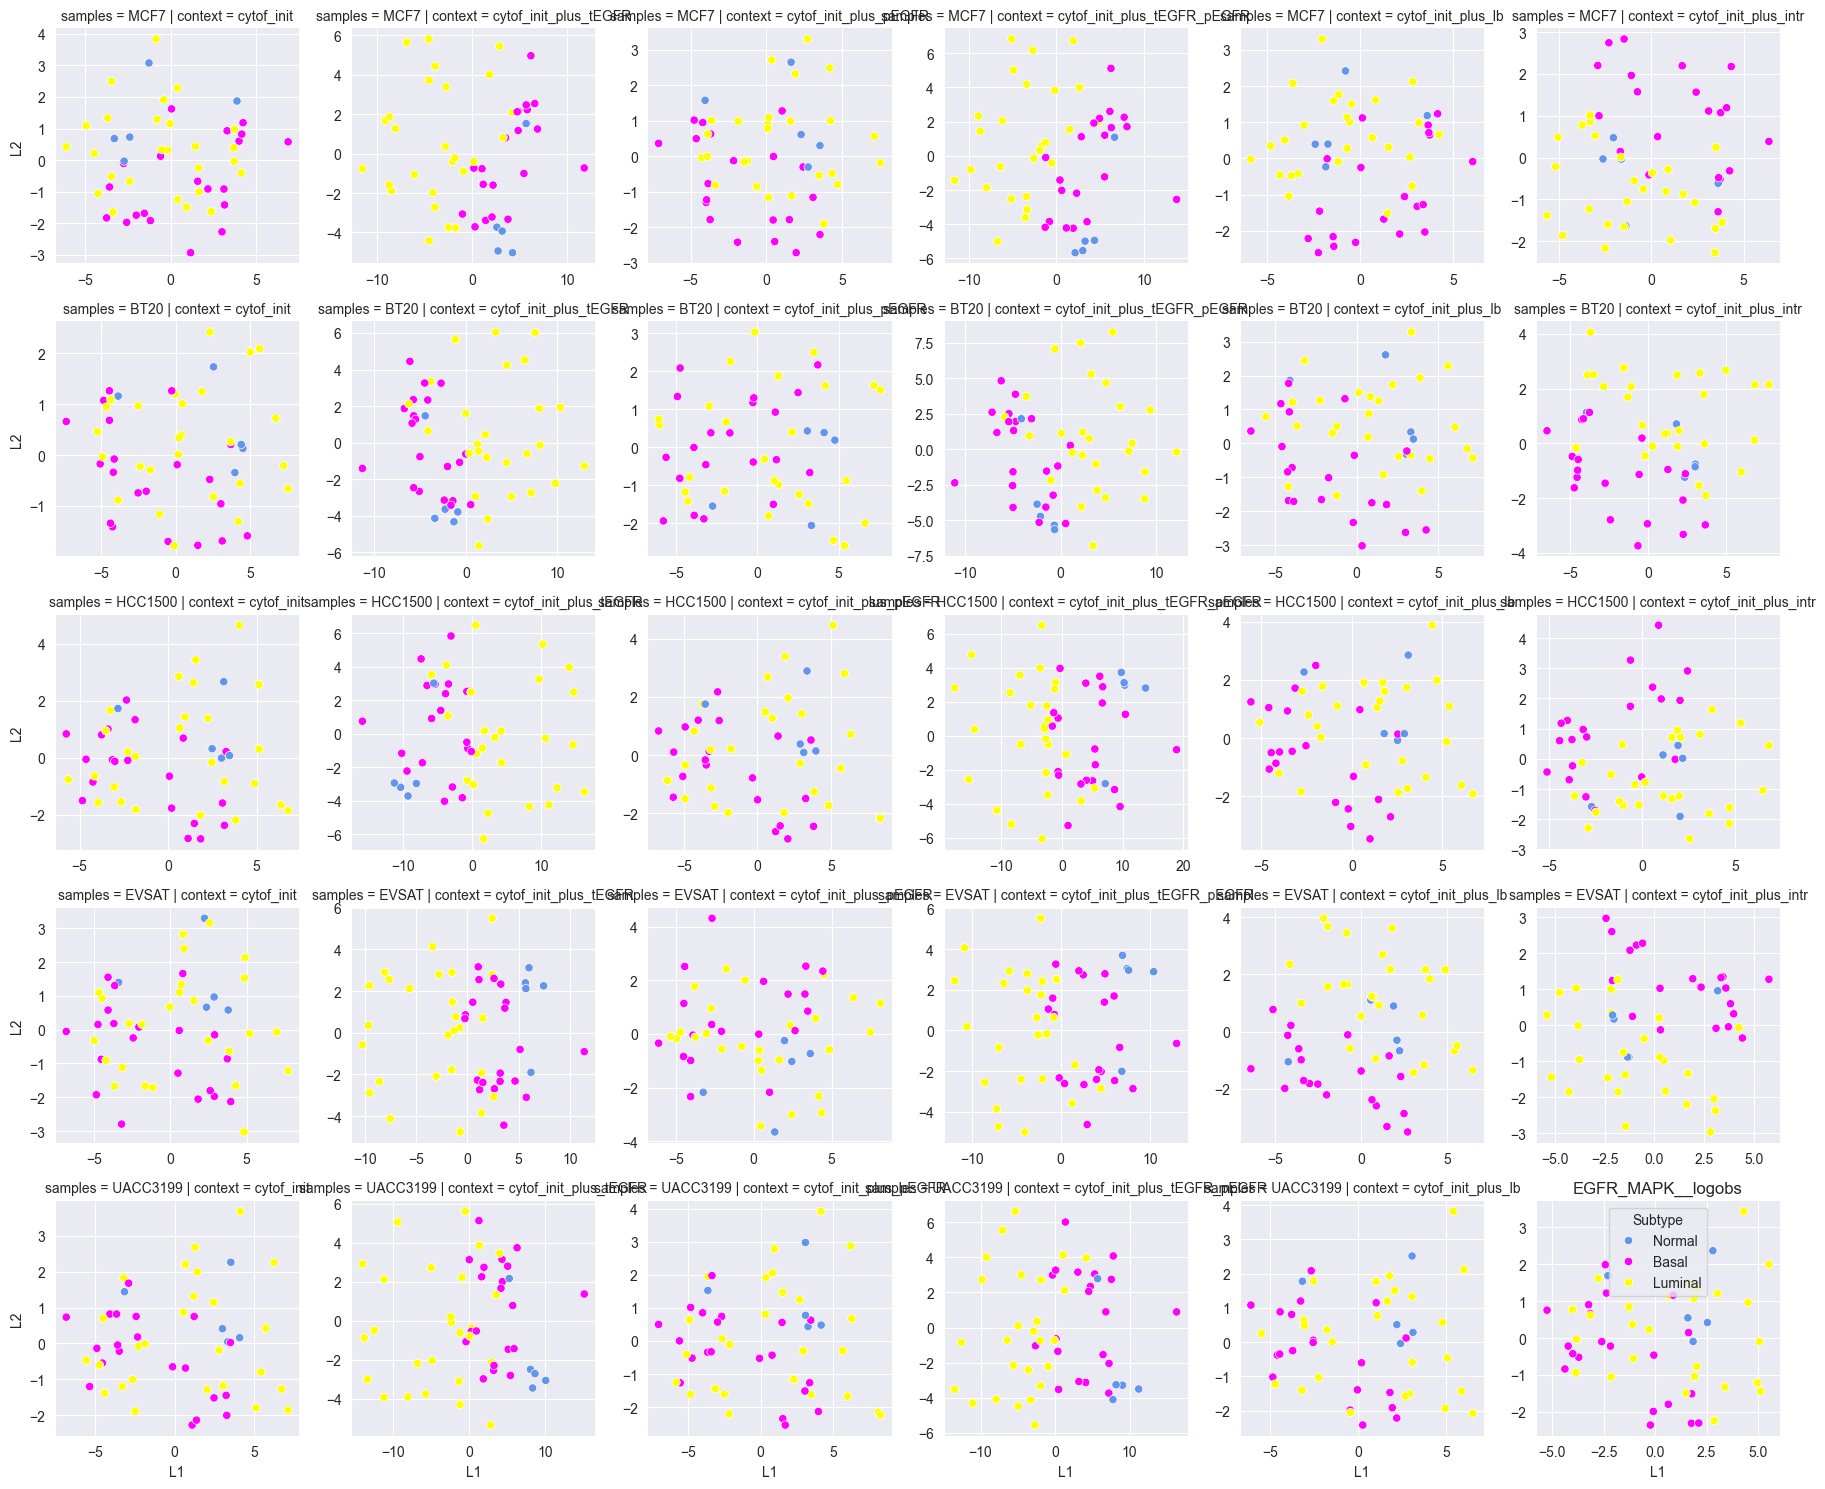

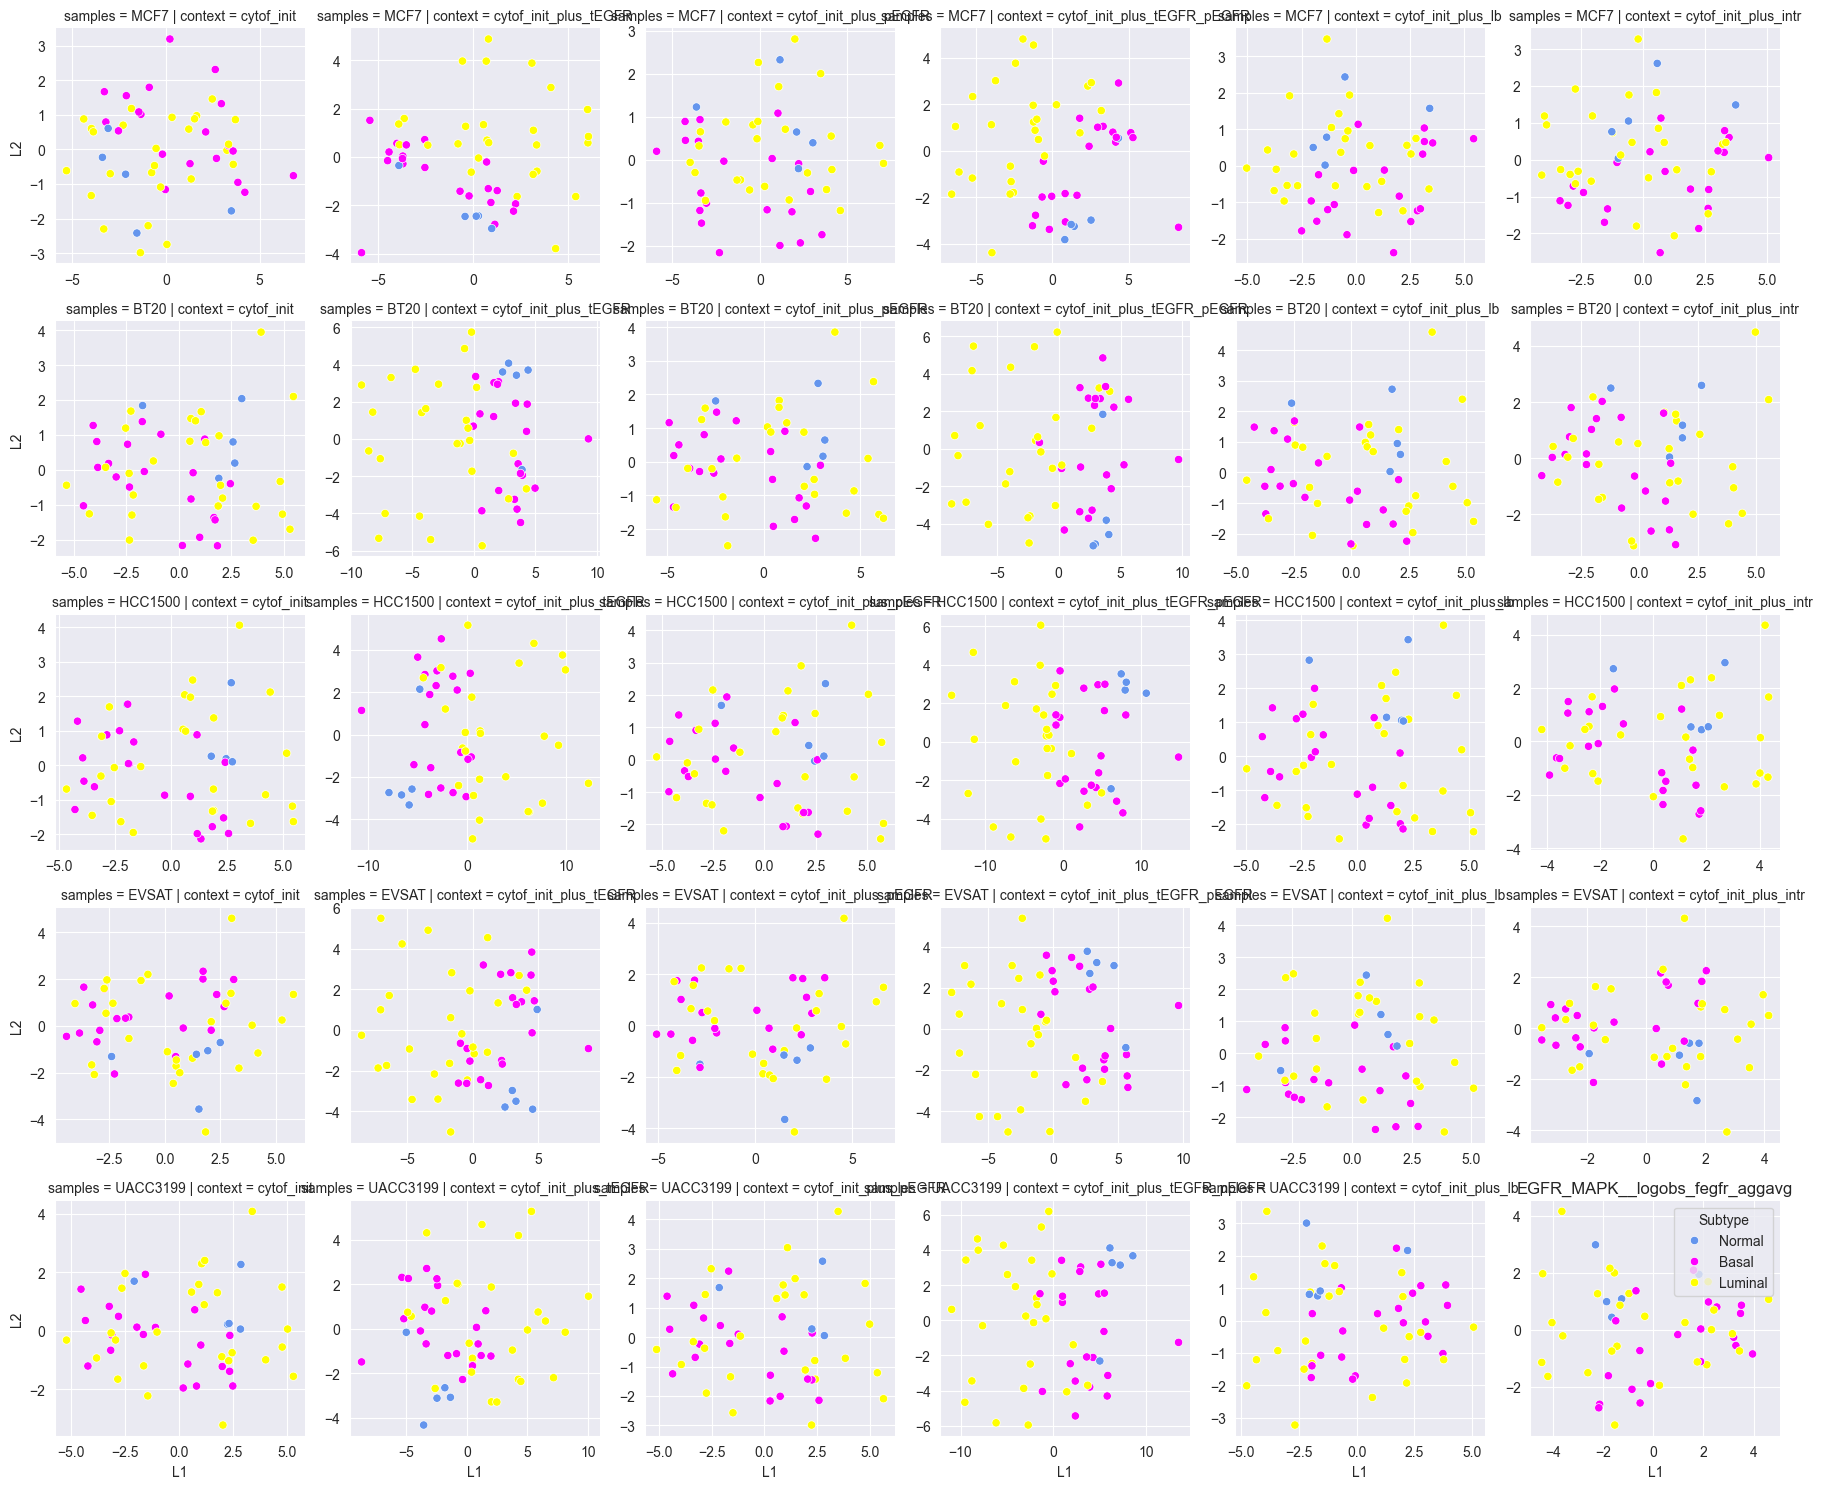

In [22]:
for model in PATHWAYS_2A:
    g = sns.FacetGrid(
        pca_embeddings_dict[model],
        row="samples",
        row_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
        col="context",
        col_order=[
            "cytof_init",
            "cytof_init_plus_tEGFR",
            "cytof_init_plus_pEGFR",
            "cytof_init_plus_tEGFR_pEGFR",
            "cytof_init_plus_lb",
            "cytof_init_plus_intr",
        ],
        sharex=False,
        sharey=False
    )

    g.map_dataframe(
        sns.scatterplot,
        x="L1",
        y="L2",
        hue="luminalbasal",
        palette={
            "Luminal": "yellow",
            "Basal": "magenta",
            "Normal": "cornflowerblue"
        }
    )

    plt.title(model)

    plt.legend(title="Subtype")
    plt.show()

EGFR_MAPK__logobs cytof_init
0.4097222222222222


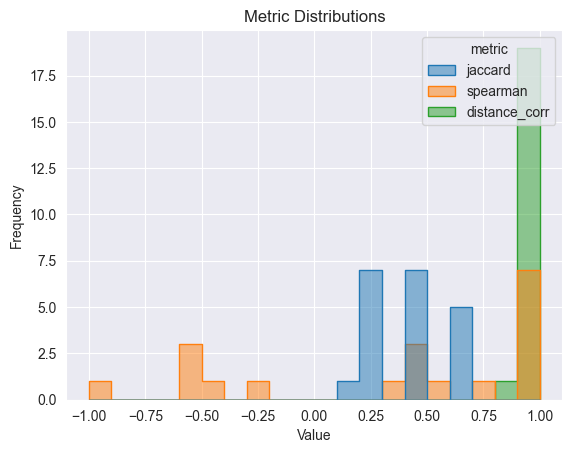

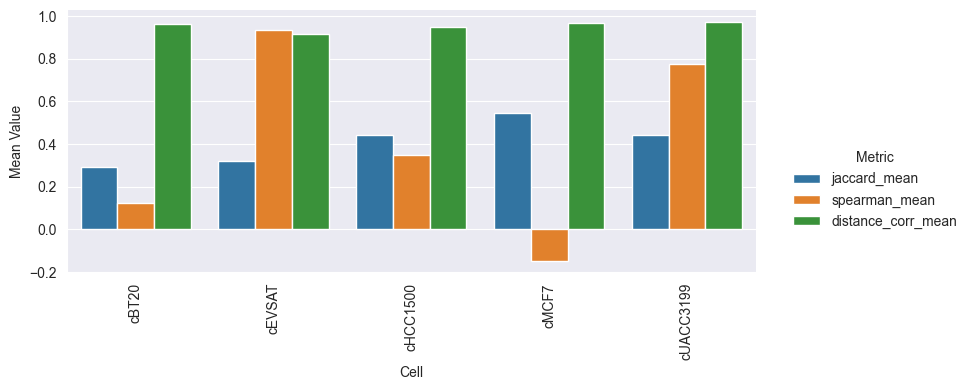

EGFR_MAPK__logobs cytof_init_plus_tEGFR
0.46011904761904754


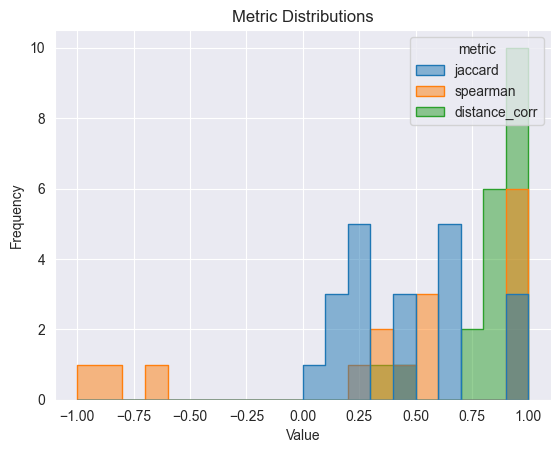

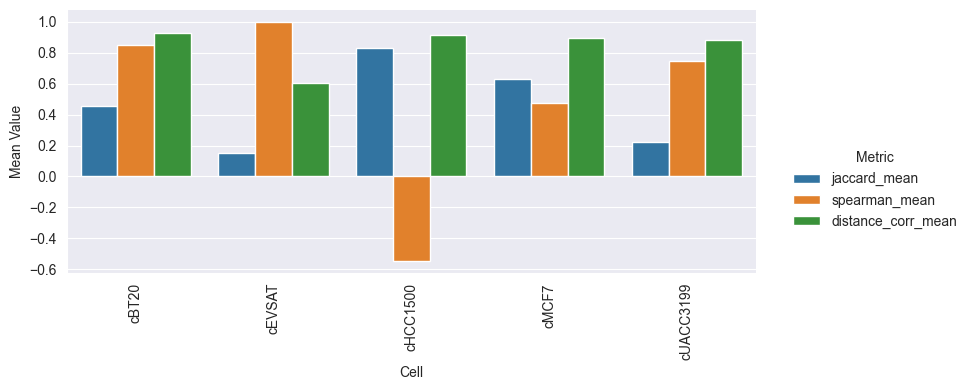

EGFR_MAPK__logobs cytof_init_plus_pEGFR
0.4226190476190476


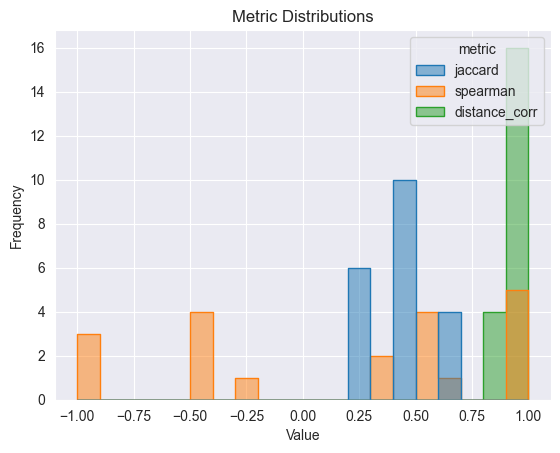

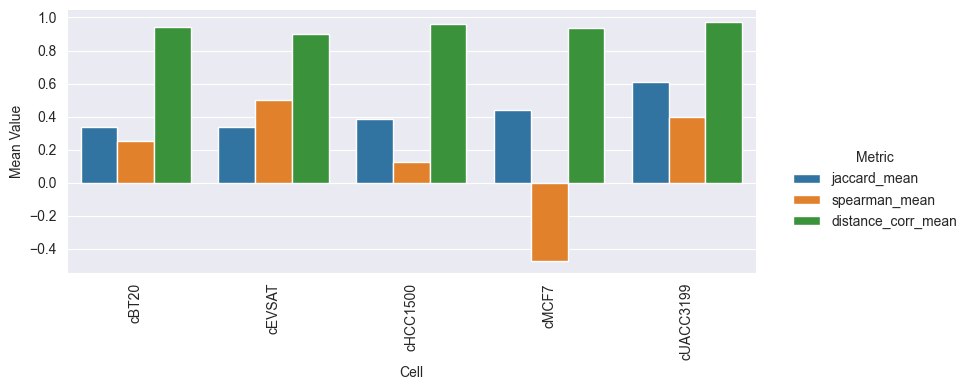

EGFR_MAPK__logobs cytof_init_plus_tEGFR_pEGFR
0.3763888888888889


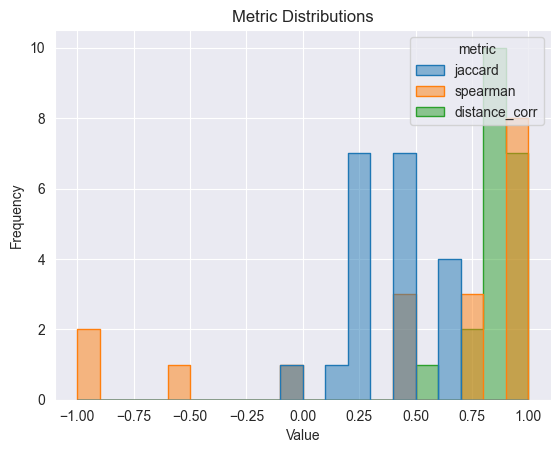

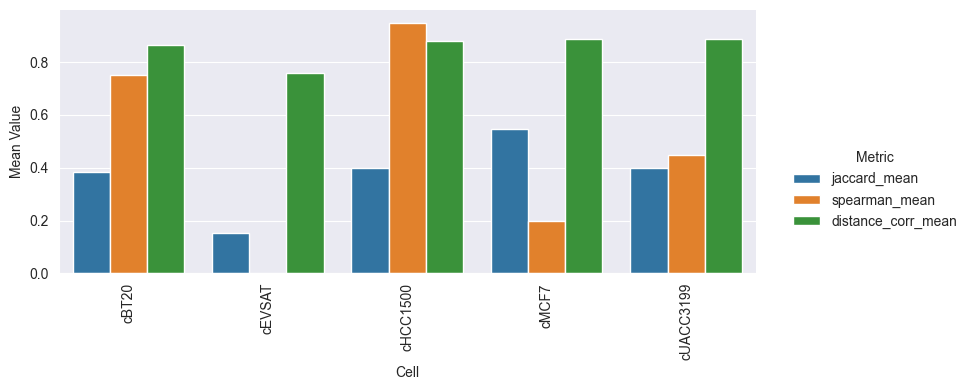

EGFR_MAPK__logobs cytof_init_plus_lb
0.44642857142857134


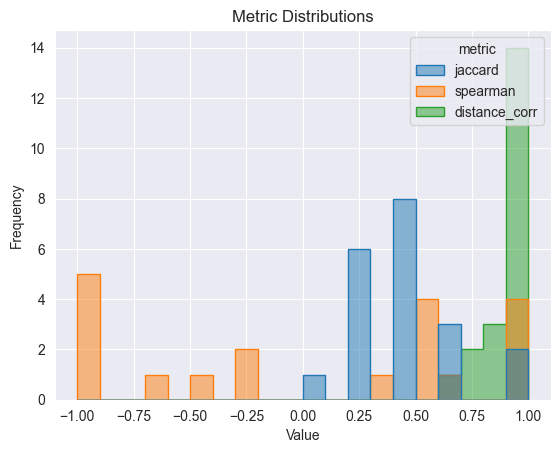

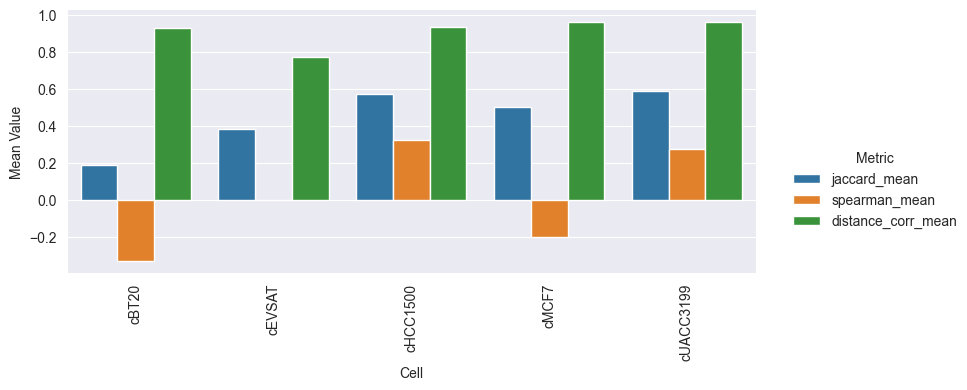

EGFR_MAPK__logobs cytof_init_plus_intr
0.49781746031746027


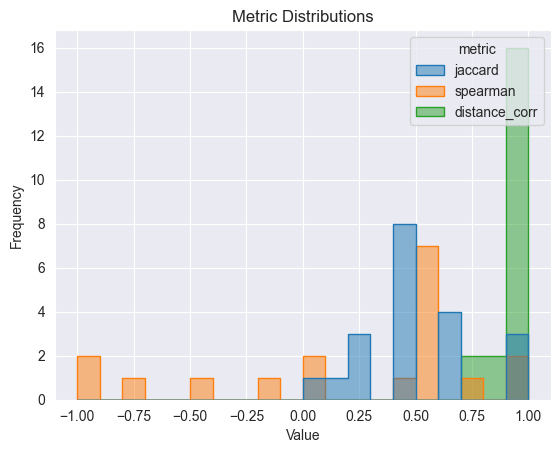

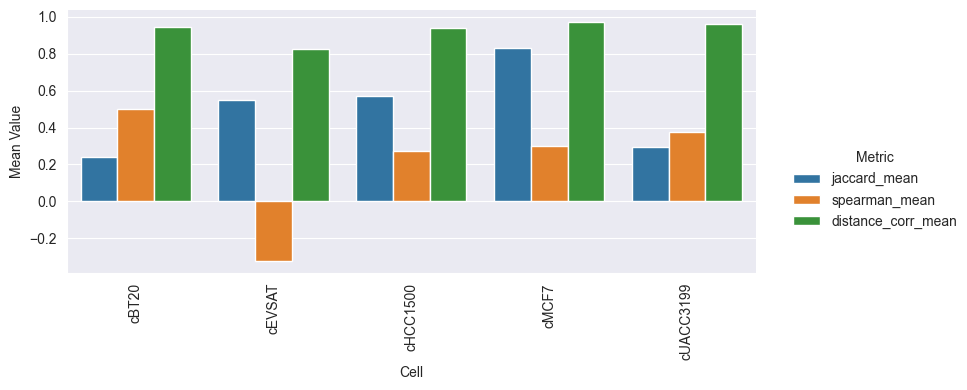

EGFR_MAPK__logobs_fegfr_aggavg cytof_init
0.39226190476190476


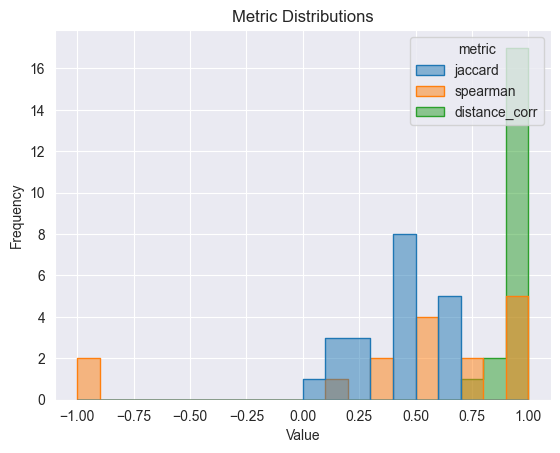

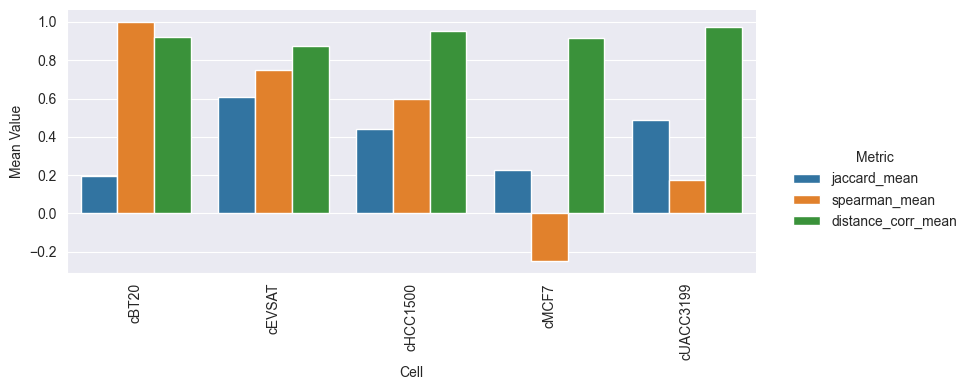

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_tEGFR
0.5738095238095238


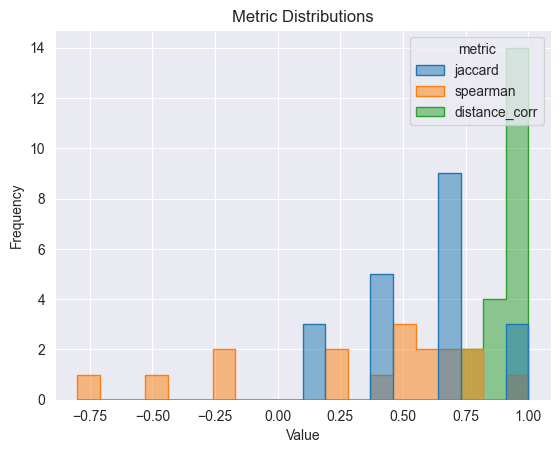

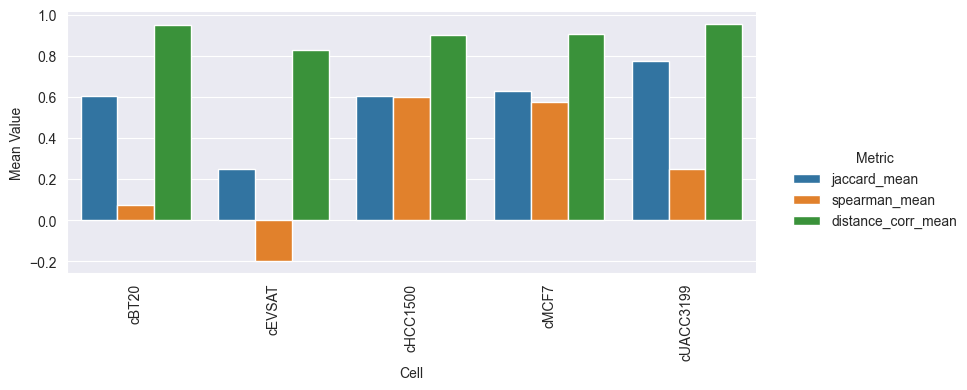

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_pEGFR
0.4652777777777778


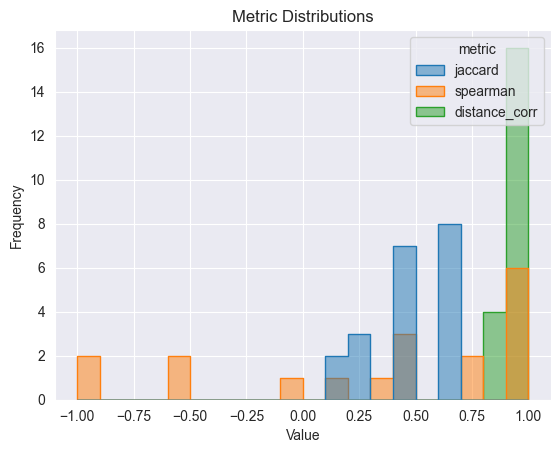

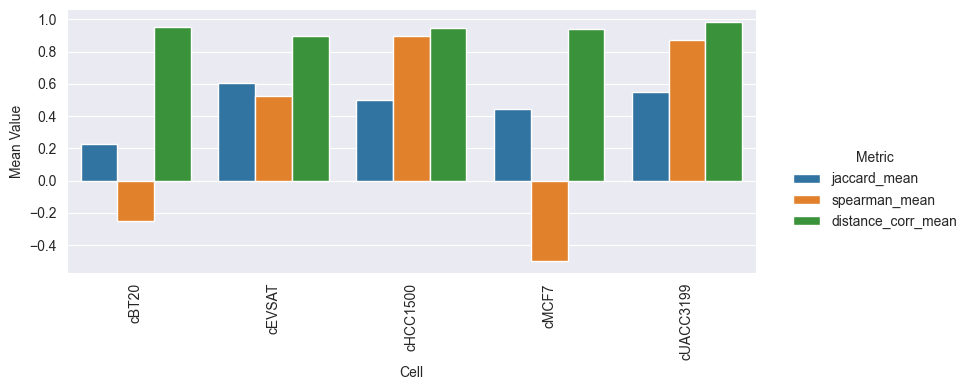

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_tEGFR_pEGFR
0.4799603174603175


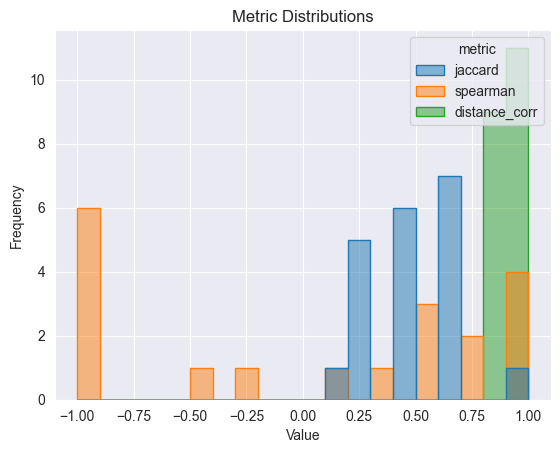

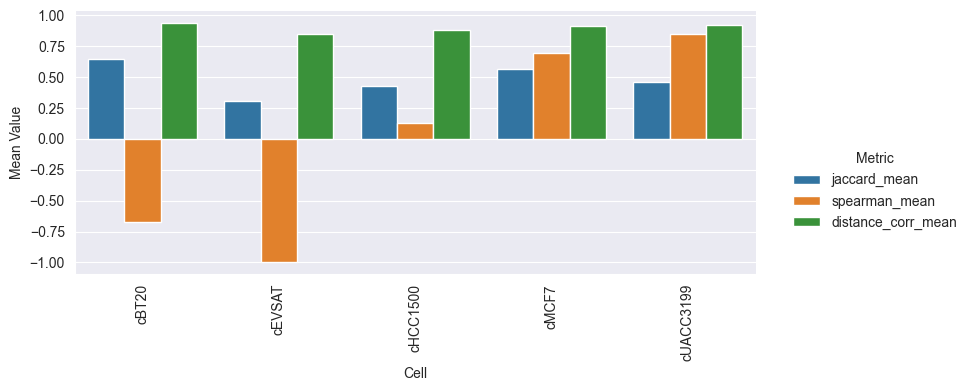

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_lb
0.42857142857142855


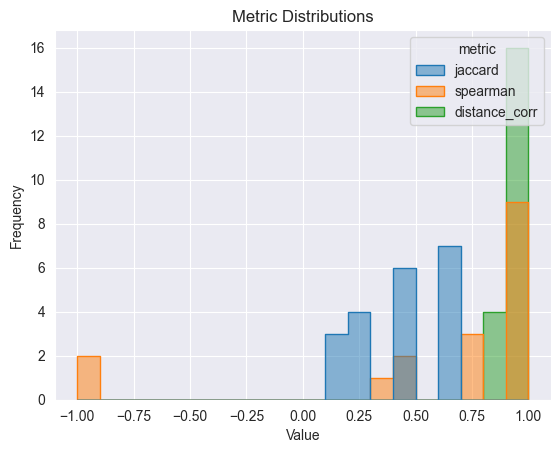

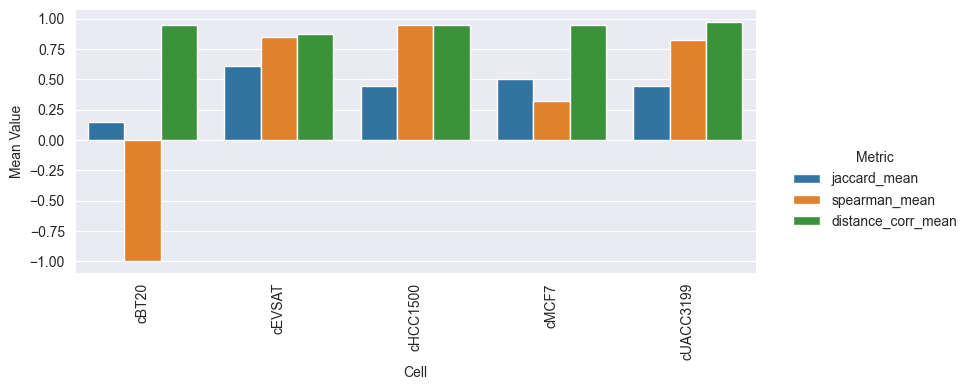

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_intr
0.3571428571428571


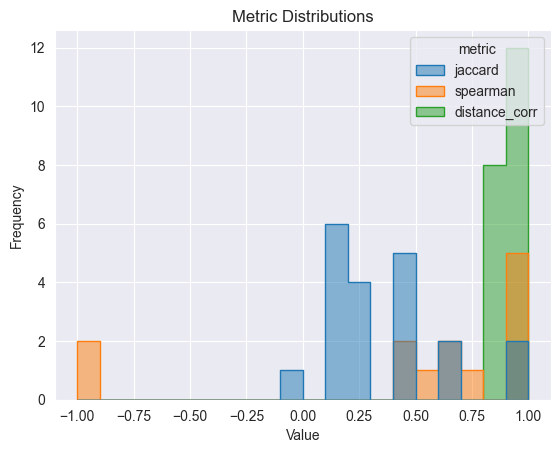

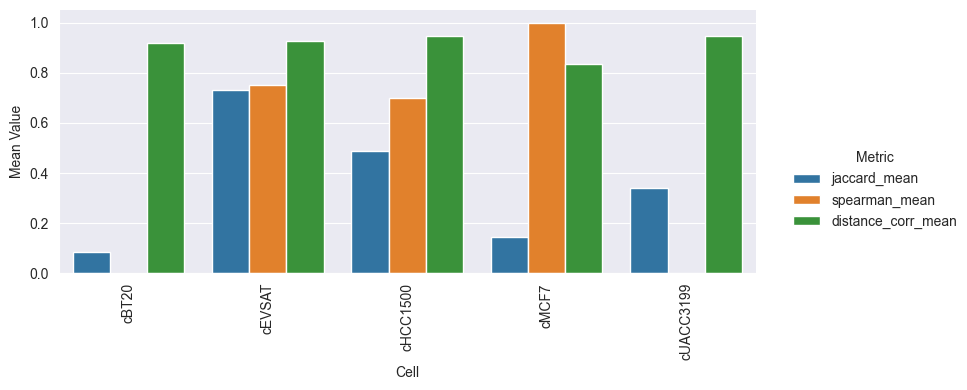

In [23]:
import itertools as itt
from embedding_consistency import *
from training_configuration import CONTEXTS_FEATURES_2A

# Compute per (split vs other_split) comparisons for each validation cell
splits = [
    "MCF7",
    "BT20",
    "HCC1500",
    "EVSAT",
    "UACC3199",
    # "MDAMB468"
]

summaries = []
for model, (context, _) in itt.product(PATHWAYS_2A, CONTEXTS_FEATURES_2A):
    print(model, context)
    per_pair = compute_validation_neighborhood_consistency(
        {split: pca_embeddings_dict[model][(pca_embeddings_dict[model]["samples"] == split) & (pca_embeddings_dict[model].context == context)][["L1", "L2"]] for split in splits},
        {split: "c"+split for split in splits},
        n_neighbors=5,      # set N here
        metric="euclidean",  # or "cosine"
    )

    # Summaries per cell
    summary = summarize_consistency(per_pair)
    print(summary.jaccard_mean.mean())
    summaries.append(summary.assign(model=model, context=context))

    plot_distribution(per_pair)
    plot_per_cell_summary(summary)

overall_summary = pd.concat(summaries)

In [24]:
overall_summary.groupby(["model", "context"]).agg({"jaccard_mean": "mean", "spearman_mean": "mean", "distance_corr_mean": "mean"})

jaccard_mean  \
model                          context                                     
EGFR_MAPK__logobs              cytof_init                       0.409722   
                               cytof_init_plus_intr             0.497817   
                               cytof_init_plus_lb               0.446429   
                               cytof_init_plus_pEGFR            0.422619   
                               cytof_init_plus_tEGFR            0.460119   
                               cytof_init_plus_tEGFR_pEGFR      0.376389   
EGFR_MAPK__logobs_fegfr_aggavg cytof_init                       0.392262   
                               cytof_init_plus_intr             0.357143   
                               cytof_init_plus_lb               0.428571   
                               cytof_init_plus_pEGFR            0.465278   
                               cytof_init_plus_tEGFR            0.573810   
                               cytof_init_plus_tEGFR_pEGFR      0.479960   

                                                            spearman_mean  \
model                          context                                      
EGFR_MAPK__logobs              cytof_init                    4.066667e-01   
                               cytof_init_plus_intr          2.250000e-01   
                               cytof_init_plus_lb            1.333333e-02   
                               cytof_init_plus_pEGFR         1.600000e-01   
                               cytof_init_plus_tEGFR         5.050000e-01   
                               cytof_init_plus_tEGFR_pEGFR   4.700000e-01   
EGFR_MAPK__logobs_fegfr_aggavg cytof_init                    4.550000e-01   
                               cytof_init_plus_intr          6.125000e-01   
                               cytof_init_plus_lb            3.900000e-01   
                               cytof_init_plus_pEGFR         3.100000e-01   
                               cytof_init_plus_tEGFR         2.600000e-01   
                               cytof_init_plus_tEGFR_pEGFR  -2.220446e-17   

                                                            distance_corr_mean  
model                          context                                          
EGFR_MAPK__logobs              cytof_init                             0.954490  
                               cytof_init_plus_intr                   0.928423  
                               cytof_init_plus_lb                     0.910531  
                               cytof_init_plus_pEGFR                  0.942745  
                               cytof_init_plus_tEGFR                  0.844619  
                               cytof_init_plus_tEGFR_pEGFR            0.856010  
EGFR_MAPK__logobs_fegfr_aggavg cytof_init                             0.928190  
                               cytof_init_plus_intr                   0.915170  
                               cytof_init_plus_lb                     0.937044  
                               cytof_init_plus_pEGFR                  0.944313  
                               cytof_init_plus_tEGFR                  0.908469  
                               cytof_init_plus_tEGFR_pEGFR            0.901020

# Top 3 consistent settings: cytof_init_plus_tEGFR with EGFR_MAPK__logobs_fegfr_aggavg (second best performing), cytof_init_plus_tEGFR_pEGFR with EGFR_MAPK__logobs_fegfr_aggavg_pobs (best performing), cytof_init_plus_tEGFR with EGFR_MAPK__logobs (VERY SURPRISING). Nonetheless, we see that the inclusion of tEGFR features is consistent in all top 3. If we combine this with performance (RMSE scores), then we are left with choosing between fegfr_aggavg_pobs with both tEGFR and pEGFR or fegfr_aggavg with tEGFR only. fegfr_aggavg with tEGFR only gets less input info AND it also displays higher mean Spearman correlation, meaning that when neighbours are the same between val and train, they also appear in more consistent distance-wise ordering/ranking.

# Trying to make sense of parameter deviations - PCA-ing across jobs/multistarts and investigating differences between train/val on val cell-lines

In [31]:
import itertools as itt
from common import evaluations_dir
from sklearn.decomposition import PCA

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure2a.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_2A
    ]
)
par_dev_df = par_dev_df[par_dev_df.samples.isin(["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"])]  # excluding MDAMB468
par_dev_df["EGFR_eq"] = par_dev_df["EGFR_eq"].fillna(1)

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset",
    "depth", "n_hidden",
    "l1reg_inflater_output", "inflater_output_reg_epoch",
    "l2reg_inflater_output",
    "recon_loss", "inflater_bound", "n_epoch", "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

median_par_dev_df = par_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].median().reset_index()


def pca_param_devs(par_dev_df):
    results_dfs = []
    for ctxt, split in itt.product(par_dev_df.context.unique(), par_dev_df.samples.unique()):
        sub_df = par_dev_df[(par_dev_df.context == ctxt) & (par_dev_df.samples == split)]
        # Compute median across job/multistart
        sub_df = sub_df.groupby(["context", "samples", "cell_line"])[param_cols].median().reset_index()
        sub_df.set_index("cell_line", inplace=True)
        pca = PCA(n_components=2)
        temp_res = pd.DataFrame(
            pca.fit_transform(sub_df[param_cols]),
            sub_df.index,
            columns=["PC1", "PC2"]
        ).assign(context=ctxt, samples=split, pca_expl = pca.explained_variance_ratio_.sum())
        results_dfs.append(temp_res)
    return pd.concat(results_dfs)


pca_param_df = pd.concat(
    [
        pca_param_devs(par_dev_df[par_dev_df.model == model]).assign(model=model)
        for model in PATHWAYS_2A
    ]
)

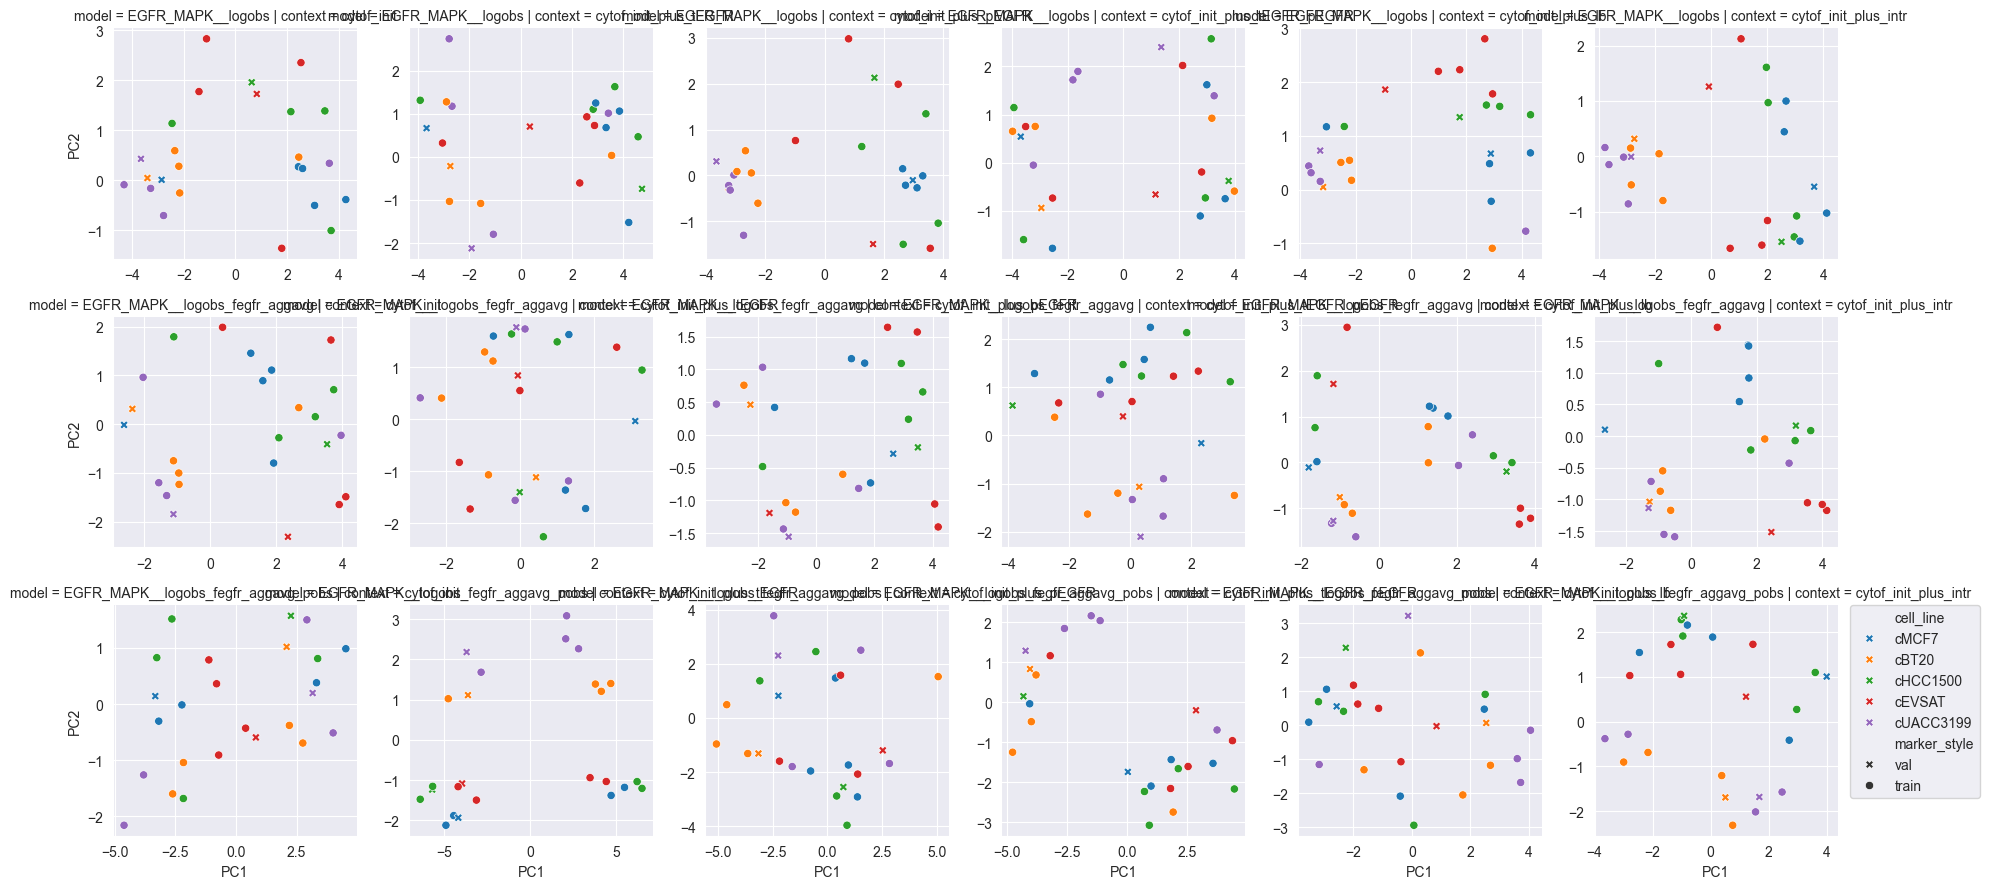

In [32]:
# Add a new column for marker style
pca_param_df["marker_style"] = pca_param_df.apply(
    lambda row: "val" if row.name[1:] == row["samples"] else "train",
    axis=1
)

# Define marker mapping
marker_dict = {"val": "X", "train": "o"}  # X for validation, circle otherwise

g = sns.FacetGrid(
    pca_param_df[pca_param_df.index.isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"])],
    col="context",
    col_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr",
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_fegfr_aggavg_pobs"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="cell_line",
    style="marker_style",        # use the new column for marker
    markers=marker_dict,         # assign specific markers
    hue_order=["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"]
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

# What do models learn for `EGFR_eq`? Do they properly use the input contexts (particularly when providing EGFR transcript/protein levels)?

In [33]:
median_egfr_eq = par_dev_df[["cell_line", "model", "context", "samples", "job", "EGFR_eq"]].groupby(["cell_line", "model", "context"]).EGFR_eq.median().reset_index()

In [34]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK", data="dream_cytof"))
del petab_base_files["condition_table"]

transcriptomics, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
del transcriptomics

proteomics, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
del proteomics

In [35]:
median_egfr_eq.set_index("cell_line", inplace=True)

In [36]:
median_egfr_eq["tEGFR"] = tegfr.loc[median_egfr_eq.index]
median_egfr_eq["pEGFR"] = pegfr.loc[median_egfr_eq.index]

# Check correlation with tEFGR

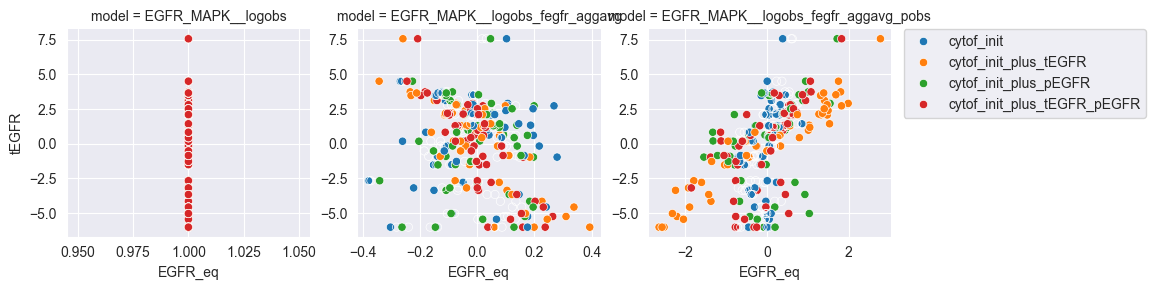

In [37]:
g = sns.FacetGrid(
    median_egfr_eq,
    col="model",
    col_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_fegfr_aggavg_pobs"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="EGFR_eq",
    y="tEGFR",
    hue="context",
    hue_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Check correlation with pEGFR (when pEGFR levels are NOT missing)

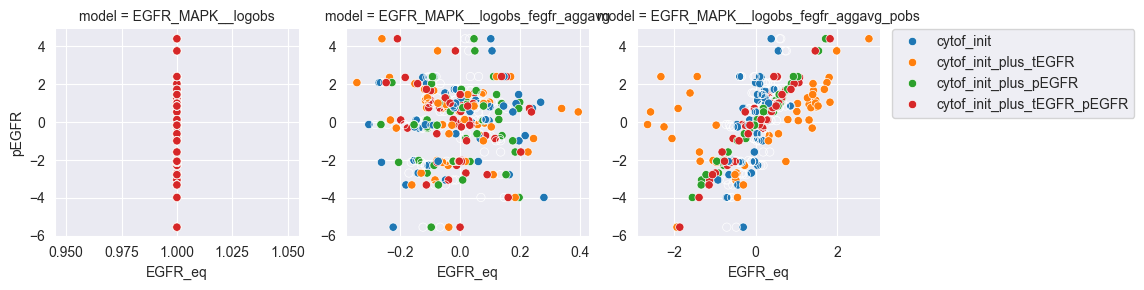

In [38]:
g = sns.FacetGrid(
    median_egfr_eq[~np.isnan(median_egfr_eq.pEGFR)],
    col="model",
    col_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_fegfr_aggavg_pobs"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="EGFR_eq",
    y="pEGFR",
    hue="context",
    hue_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [39]:

np.corrcoef(
    [median_egfr_eq[(median_egfr_eq.model == "EGFR_MAPK__logobs_fegfr_aggavg_pobs") & (median_egfr_eq.context == "cytof_init_plus_tEGFR")][["EGFR_eq"]].values.reshape(-1, ),
    median_egfr_eq[(median_egfr_eq.model == "EGFR_MAPK__logobs_fegfr_aggavg_pobs") & (median_egfr_eq.context == "cytof_init_plus_tEGFR")][["tEGFR"]].values.reshape(-1, )]
)

array([[1.        , 0.95879025],
       [0.95879025, 1.        ]])

In [40]:
import itertools as itt
import numpy as np
import pandas as pd

# collect results in a list of dicts instead of nested dict
results = []

for model, (context, _), marker in itt.product(
        PATHWAYS_2A, CONTEXTS_FEATURES_2A, ["tEGFR", "pEGFR"]
):
    subset = median_egfr_eq[(median_egfr_eq.model == model) & (median_egfr_eq.context == context)]
    egfr_eq = subset["EGFR_eq"].values
    marker_levels = subset[marker].values

    mask = ~np.isnan(marker_levels)
    if mask.sum() > 1:  # need at least 2 points to compute correlation
        corr = np.corrcoef(egfr_eq[mask], marker_levels[mask])[0, 1]
    else:
        corr = np.nan

    results.append({
        "model": model,
        "context": context,
        "marker": marker,
        "correlation": corr
    })

# Convert to tidy dataframe
df_corr = pd.DataFrame(results)

# Optional: sort for readability
df_corr = df_corr.sort_values(["model", "context", "marker"]).reset_index(drop=True)

df_corr

,model,context,marker,correlation
0,EGFR_MAPK__logobs,cytof_init,pEGFR,NaN
1,EGFR_MAPK__logobs,cytof_init,tEGFR,NaN
2,EGFR_MAPK__logobs,cytof_init_plus_intr,pEGFR,NaN
3,EGFR_MAPK__logobs,cytof_init_plus_intr,tEGFR,NaN
4,EGFR_MAPK__logobs,cytof_init_plus_lb,pEGFR,NaN
5,EGFR_MAPK__logobs,cytof_init_plus_lb,tEGFR,NaN
6,EGFR_MAPK__logobs,cytof_init_plus_pEGFR,pEGFR,NaN
7,EGFR_MAPK__logobs,cytof_init_plus_pEGFR,tEGFR,NaN
8,EGFR_MAPK__logobs,cytof_init_plus_tEGFR,pEGFR,NaN
9,EGFR_MAPK__logobs,cytof_init_plus_tEGFR,tEGFR,NaN


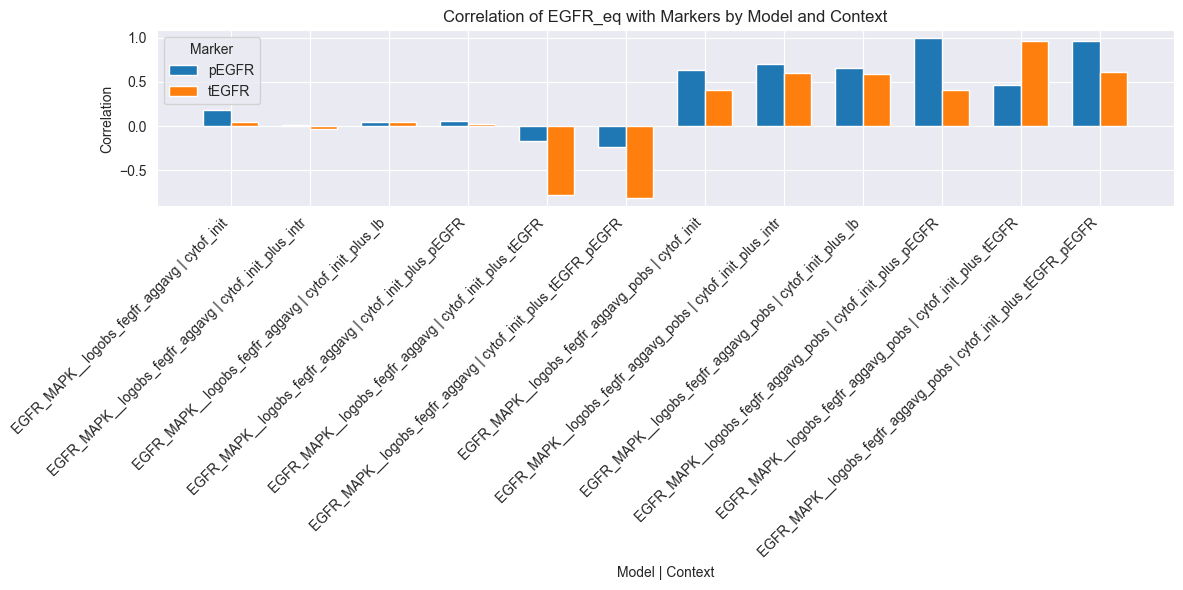

In [41]:
plt.figure(figsize=(12, 6))

# Pivot for easier grouped plotting
pivot_df = df_corr.pivot_table(
    index=["model", "context"],
    columns="marker",
    values="correlation"
).reset_index()

markers = df_corr["marker"].unique()
bar_width = 0.35
x = np.arange(len(pivot_df))  # one position per model-context pair

for i, marker in enumerate(markers):
    plt.bar(
        x + i * bar_width,
        pivot_df[marker],
        width=bar_width,
        label=marker
    )

plt.xticks(
    x + bar_width / 2,
    pivot_df[["model", "context"]].agg(" | ".join, axis=1),
    rotation=45, ha="right"
)
plt.ylabel("Correlation")
plt.xlabel("Model | Context")
plt.title("Correlation of EGFR_eq with Markers by Model and Context")
plt.legend(title="Marker")
plt.tight_layout()
plt.show()

In [42]:
tegfr_values = tegfr.values.reshape(-1, )
pegfr_values = pegfr.values.reshape(-1, )
mask_valid = (~np.isnan(tegfr_values) & ~np.isnan(pegfr_values))
base_tegfr_pegfr_corr = np.corrcoef(
    tegfr_values[mask_valid],
    pegfr_values[mask_valid]
)[0, 1]

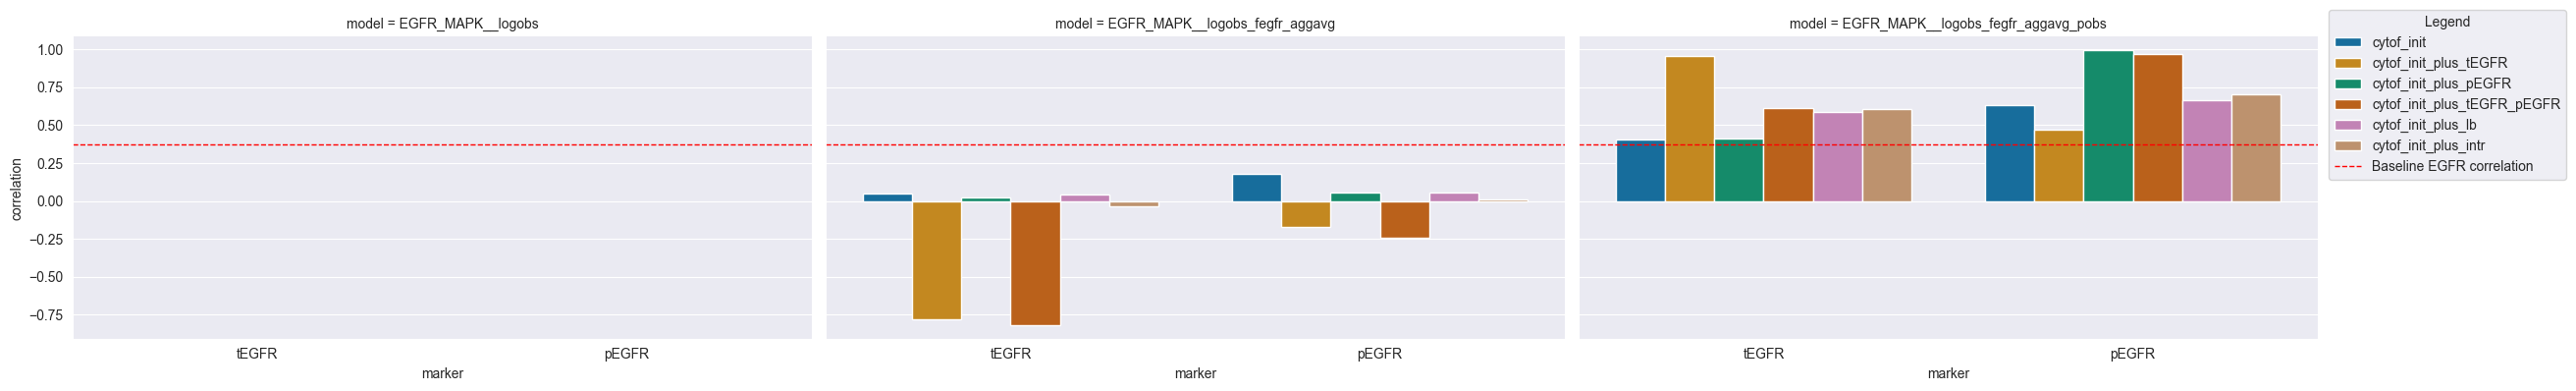

In [43]:
from matplotlib.lines import Line2D

g = sns.FacetGrid(
    df_corr,
    col="model",
    col_order=[
        "EGFR_MAPK__logobs",
        "EGFR_MAPK__logobs_fegfr_aggavg",
        "EGFR_MAPK__logobs_fegfr_aggavg_pobs"
    ],
    height=4,
    aspect=2
)

# Map barplots
g.map_dataframe(
    sns.barplot,
    x="marker",
    order=["tEGFR", "pEGFR"],
    y="correlation",
    hue="context",
    hue_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr",
    ],
    palette=sns.color_palette("colorblind"),
    dodge=True
)

# Add horizontal line in each facet
for ax in g.axes.flat:
    ax.axhline(base_tegfr_pegfr_corr, color="red", linestyle="--", linewidth=1)

# Add legend for contexts (Seaborn handles this)
g.add_legend(title="Input context")

# Add custom legend handle for baseline
baseline_handle = Line2D(
    [0], [0],
    color="red", linestyle="--", linewidth=1,
    label="Baseline tEGFR-pEGFR correlation"
)

# Append baseline to existing legend
handles, labels = g._legend.legendHandles, [t.get_text() for t in g._legend.get_texts()]
handles.append(baseline_handle)
labels.append("Baseline EGFR correlation")
g._legend.remove()
g.fig.legend(handles, labels, title="Legend", bbox_to_anchor=(0.90, 1), loc="upper left")

plt.show()

In [44]:
tegfr_values = tegfr.values.reshape(-1, )
pegfr_values = pegfr.values.reshape(-1, )
mask_valid = (~np.isnan(tegfr_values) & ~np.isnan(pegfr_values))
np.corrcoef(
    tegfr_values[mask_valid],
    pegfr_values[mask_valid]
)

array([[1.        , 0.37469522],
       [0.37469522, 1.        ]])

In [45]:
transcriptomics, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)

In [46]:
(transcriptomics["EGFR"] - transcriptomics["EGFR"].mean()).sort_index()

preequilibrationConditionId
c184A1          3.735654
c184B5          4.504654
cBT20           2.904654
cBT474         -0.909346
cBT483         -2.789346
cBT549          2.207654
cCAL148         0.198654
cCAL51         -0.169346
cCAL851         2.729654
cDU4475        -4.152346
cEFM192A       -6.016346
cEVSAT         -2.669346
cHBL100         0.623654
cHCC1187        2.069654
cHCC1395        1.291654
cHCC1419       -5.246346
cHCC1428       -1.526346
cHCC1500       -6.016346
cHCC1569       -0.165346
cHCC1806        3.113654
cHCC1937        2.386654
cHCC1954        0.973654
cHCC202         0.178654
cHCC2185        2.078654
cHCC3153        1.332654
cHCC38          1.177654
cHCC70          3.525654
cHDQP1          2.134654
cHs578T         2.191654
cJIMT1          2.808654
cMCF10A         3.470654
cMCF12A         3.655654
cMCF7          -3.362346
cMDAMB134VI    -5.446346
cMDAMB157       1.292654
cMDAMB175VII   -0.967346
cMDAMB231       2.517654
cMDAMB361      -0.520346
cMDAMB415      -4.5683

In [47]:
median_egfr_eq.loc["cMDAMB468"]

,model,context,EGFR_eq,tEGFR,pEGFR
cell_line,,,,,
cMDAMB468,EGFR_MAPK__logobs,cytof_init,1.000000,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs,cytof_init_plus_intr,1.000000,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs,cytof_init_plus_lb,1.000000,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs,cytof_init_plus_pEGFR,1.000000,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs,cytof_init_plus_tEGFR,1.000000,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs,cytof_init_plus_tEGFR_pEGFR,1.000000,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs_fegfr_aggavg,cytof_init,0.102290,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs_fegfr_aggavg,cytof_init_plus_intr,0.016934,7.563654,4.404719
cMDAMB468,EGFR_MAPK__logobs_fegfr_aggavg,cytof_init_plus_lb,0.031675,7.563654,4.404719


In [48]:
median_egfr_eq.loc["cBT20"]

,model,context,EGFR_eq,tEGFR,pEGFR
cell_line,,,,,
cBT20,EGFR_MAPK__logobs,cytof_init,1.000000,2.904654,3.764672
cBT20,EGFR_MAPK__logobs,cytof_init_plus_intr,1.000000,2.904654,3.764672
cBT20,EGFR_MAPK__logobs,cytof_init_plus_lb,1.000000,2.904654,3.764672
cBT20,EGFR_MAPK__logobs,cytof_init_plus_pEGFR,1.000000,2.904654,3.764672
cBT20,EGFR_MAPK__logobs,cytof_init_plus_tEGFR,1.000000,2.904654,3.764672
cBT20,EGFR_MAPK__logobs,cytof_init_plus_tEGFR_pEGFR,1.000000,2.904654,3.764672
cBT20,EGFR_MAPK__logobs_fegfr_aggavg,cytof_init,0.106300,2.904654,3.764672
cBT20,EGFR_MAPK__logobs_fegfr_aggavg,cytof_init_plus_intr,-0.014497,2.904654,3.764672
cBT20,EGFR_MAPK__logobs_fegfr_aggavg,cytof_init_plus_lb,0.028548,2.904654,3.764672


This really does not make sense...MDA-MB-468 has even higher tEGFR (and slightly higher pEGFR) levels than BT-20...but our supposed mechanism does not help at all!

In [49]:
# par_dev_df = par_dev_df.reset_index()
median_params = par_dev_df.groupby(["cell_line", "model", "context"])[param_cols].median().reset_index()

In [50]:
def get_abs_diff(
        df,
        model1, context1,
        model2, context2,
        index_col, param_cols,
        plot
):
    df1 = df[
        (df["model"] == model1) & (df["context"] == context1)
    ]
    df1.set_index(index_col, inplace=True)
    df1.sort_index(inplace=True)

    df2 = df[
        (df["model"] == model2) & (df["context"] == context2)
    ]
    df2.set_index(index_col, inplace=True)
    df2.sort_index(inplace=True)

    abs_diff = pd.DataFrame(
        np.abs(
            df1[param_cols].values - df2[param_cols].values
        ),
        index=df1[param_cols].index,
        columns=param_cols,
    )

    if plot:
        sns.clustermap(
            abs_diff,
            cmap="coolwarm",
        )

    return abs_diff

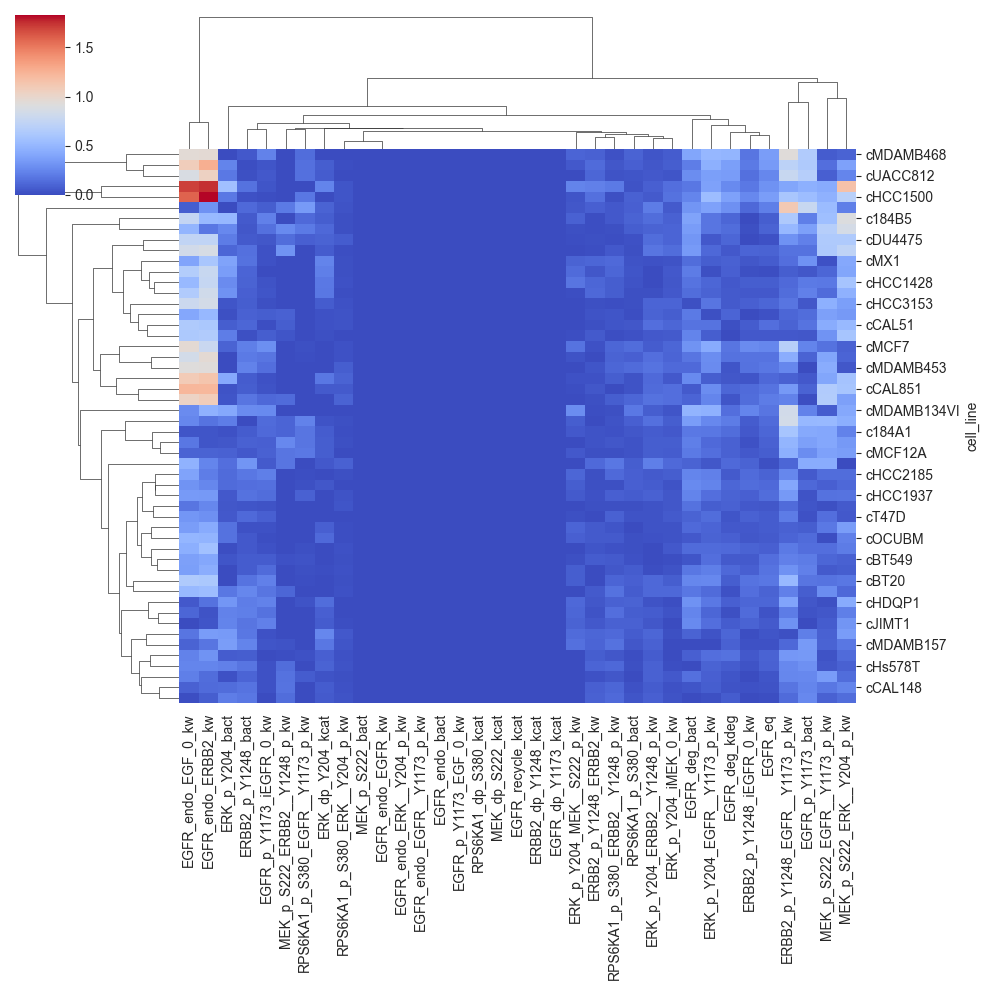

In [51]:
_ = get_abs_diff(
    median_params,
    "EGFR_MAPK__logobs_fegfr_aggavg",
    "cytof_init",
    "EGFR_MAPK__logobs_fegfr_aggavg",
    "cytof_init_plus_tEGFR",
    "cell_line",
    param_cols,
    True
)

In [74]:
def rank_median_param_correlations_to_marker(df, param_cols, marker_values, top_n=5):
    correlations = {}

    for param_col in param_cols:
        if param_col in df.columns:
            median_param = (
                df[["cell_line", "model", "context", "samples", "job", param_col]]
                .groupby(["cell_line", "model", "context"])[param_col]
                .median()
                .reset_index()
                .set_index("cell_line")
            )

            aligned_markers = marker_values.loc[median_param.index]
            mask_valid_markers = ~np.isnan(aligned_markers)

            # If marker_values is a Series
            try:
                correlations[param_col] = np.corrcoef(
                    median_param[param_col].values[mask_valid_markers],
                    aligned_markers.values[mask_valid_markers]
                )[0, 1]
            except Exception:
                correlations[param_col] = np.nan
        else:
            correlations[param_col] = np.nan

    # Convert to Series for easy ranking
    corr_series = pd.Series(correlations)

    # Drop NaNs, rank by absolute value, keep top_n
    ranked = corr_series.dropna().reindex(
        corr_series.dropna().abs().sort_values(ascending=False).index
    ).head(top_n)

    return ranked

In [81]:
rank_median_param_correlations_to_marker(
    par_dev_df[
        (par_dev_df.model == "EGFR_MAPK__logobs_fegfr_aggavg")
        &
        (par_dev_df.context == "cytof_init_plus_tEGFR")
    ],
    param_cols,
    tegfr,
    top_n=10
)

EGFR_p_Y1173_bact                  0.900152
ERK_p_Y204_EGFR__Y1173_p_kw       -0.866096
ERBB2_p_Y1248_EGFR__Y1173_p_kw     0.854843
RPS6KA1_p_S380_EGFR__Y1173_p_kw   -0.789178
EGFR_eq                           -0.777391
EGFR_deg_bact                     -0.736152
ERBB2_p_Y1248_iEGFR_0_kw           0.711489
EGFR_deg_kdeg                     -0.662788
MEK_p_S222_EGFR__Y1173_p_kw        0.640017
EGFR_endo_ERBB2_kw                -0.617428
dtype: float64